**Training script for mediapipe->TCN regression chain**

In [80]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import RandomOverSampler

In [90]:
df = pd.read_csv("data/dataset/spreidsprong/csv/labels.csv")
df.head()

,video_name,aanloop,afstoot,zweeffase_1,zweeffase_2,landing
0,img_s1.mp4,1,1,1,1,1
1,img_s2.mp4,1,1,1,1,1
2,img_s3.mp4,1,1,1,1,1
3,img_s4.mp4,1,1,1,1,1
4,img_s5.mp4,1,1,1,1,1


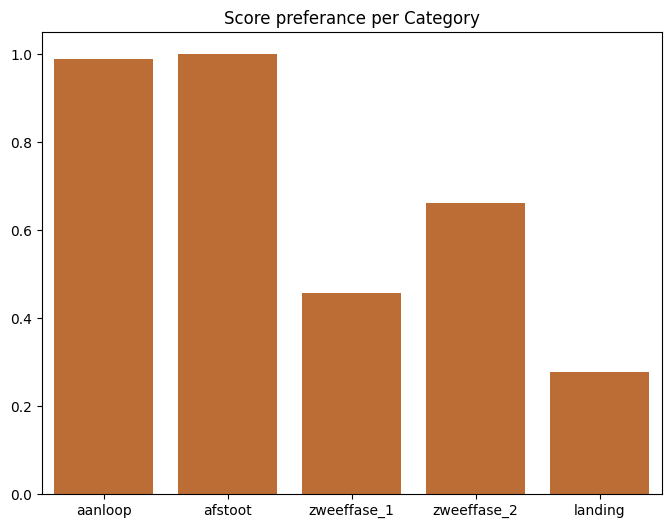

In [91]:
col_means = df.drop(columns=["video_name"]).mean()
df = df.drop(columns=[key for key, val in col_means.to_dict().items() if abs(val-0.5) > 0.8])

col_means = df.drop(columns=["video_name"]).mean()
plt.figure(figsize=(8, 6))
sns.barplot(data=col_means, color="chocolate")
plt.title("Score preferance per Category")
plt.show()

Data is highly unbalanced. Need more bad tries.

In [84]:
# Oversampling
# Separate features and labels
video_names = df["video_name"]
y = df.drop(columns=["video_name"])

y_str = y.astype(str).agg("".join, axis=1)  # e.g. "101", "011"
print("Unique label combos:\n", y_str.value_counts(), "\n")

ros = RandomOverSampler(random_state=42)
x = np.arange(len(df)).reshape(-1, 1)  # dummy numeric index
x_res, y_res = ros.fit_resample(x, y_str)


resampled_videos = video_names.iloc[x_res.flatten()].reset_index(drop=True)
y_res_split = pd.DataFrame(y_res.apply(lambda s: list(map(int, list(s)))).tolist(),
                           columns=y.columns)

df_balanced = pd.concat([resampled_videos, y_res_split], axis=1)


Unique label combos:
 010    21
000    20
111    18
110    13
100     6
011     3
001     1
101     1
Name: count, dtype: int64 



In [86]:
df_balanced.tail()

,video_name,zweeffase_1,zweeffase_2,landing
163,img_s17.mp4,1,1,0
164,img_s42.mp4,1,1,0
165,img_s8.mp4,1,1,1
166,img_s11.mp4,1,1,1
167,img_s8.mp4,1,1,1


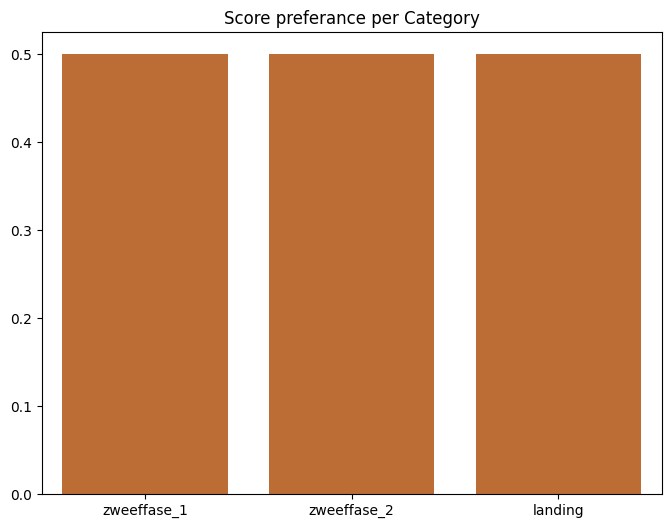

In [ ]:
col_means = df_balanced.drop(columns=["video_name"]).mean()
plt.figure(figsize=(8, 6))
sns.barplot(data=col_means, color="chocolate")
plt.title("Score preferance per Category - Balanced")
plt.show()

In [ ]:
# Convert all data to mediapipe segment data